# Factor Exposures and Idiosyncratic Risk of Apple

---

## Introduction

The lecture objective is to get the **factor exposures** and **idiosyncratic risk** of a common stock, Apple, using Python.

This is important for investors, portfolio managers, and analysts. It is the kind of problem that gets solved every day.

We will:

- Download the Fama-French 3 factor data (market, size, value) plus the risk-free rate.
- Download the momentum factor.
- Merge all four factor return series into a single data frame.
- Download Apple stock data from Yahoo Finance.
- Align Apple's monthly returns with the monthly factor returns.
- Run an OLS factor model regression with a constant (alpha).
- Extract the factor exposures (betas), alpha, and idiosyncratic risk.

---

## Notebook Roadmap

1. Setup & Imports
2. Start Date & Available Datasets
3. Download Fama-French 3 Factor Data
4. Download Momentum Factor
5. Merge the Four Factor Return Series
6. Download Apple Stock Data
7. Align Apple and Factor Indexes
8. Merge Apple Returns with Factor Returns
9. Clean Column Names
10. Create Apple Excess Returns
11. Drop Missing Values
12. Run Factor Model Regression
13. Extract Factor Exposures and Idiosyncratic Risk
14. Interpretation

## 1. Setup & Imports

We begin by importing the libraries used throughout the notebook:

- **pandas** — data handling and plotting.
- **pandas_datareader** — connections to many financial datasets, including Ken French's data library.
- **yfinance** — a modern workaround for broken Yahoo Finance access; we download Apple data directly with it.
- **matplotlib** — a common plotting tool.

We alias `matplotlib.pyplot` as `plt` so we do not have to type the full name every time.

In [1]:
import pandas as pd
from pandas_datareader.famafrench import FamaFrenchReader
import matplotlib.pyplot as plt
import yfinance as yf

# yfinance is used as a workaround for broken Yahoo Finance access.
# We download Apple data directly with yfinance rather than through
# pandas_datareader (newer yfinance versions removed pdr_override).


## 2. Start Date & Available Datasets

We want the factor data to start as far back as possible. Fama-French factor data is maintained back to 1926.

Ken French's data library contains returns of common risk factors. Depending on your pandas-datareader version, the method to list available datasets may be named `get_available_datasets()` or `get_available_data()`.

The important datasets for this notebook are:

- `"F-F_Research_Data_Factors"` — Fama-French 3 factors + risk-free rate
- `"F-F_Momentum_Factor"` — momentum factor

In [2]:
# Create a start variable: January 1, 1926.
start = "1926-01-01"

In [3]:
# Optional: inspect available Fama-French datasets.
# Depending on your pandas-datareader version, the method may be named:
#
# print(FamaFrenchReader.get_available_datasets())
#
# or:
#
# print(FamaFrenchReader.get_available_data())

## 3. Download Fama-French 3 Factor Data

Use pandas_datareader with the start date to get the Fama-French three factors from 1926 onward.

The dataset name is `"F-F_Research_Data_Factors"`. We specify frequency `"M"` (monthly).

> **Important transcript point:** Daily factor returns are far too noisy. Monthly returns usually give better factor sensitivity estimates.

The object returned by the reader is not exactly one simple data frame; it contains two elements:

- Element zero is the monthly data frame.
- Element one is the annual data.

> **Important Python point:** Python is zero-indexed, so the first element is accessed with `[0]`.

The monthly data frame has four columns: three Fama-French factors plus the risk-free rate.

In [4]:
ff = FamaFrenchReader(
    "F-F_Research_Data_Factors",
    freq="M",
    start=start
).read()

# The object returned contains two elements.
# Element zero is the monthly data frame; element one is annual data.
ff_df = ff[0]

print(ff_df.head())

         Mkt-RF   SMB   HML    RF
Date                             
1926-07    2.89 -2.55 -2.39  0.22
1926-08    2.64 -1.14  3.81  0.25
1926-09    0.38 -1.36  0.05  0.23
1926-10   -3.27 -0.14  0.82  0.32
1926-11    2.54 -0.11 -0.61  0.31


### Plot factor returns

pandas lets us plot the elements in the data frame. First, plot the raw returns themselves. The raw monthly factor return series are noisy and squiggly.

Instead, plot smoothed moving averages. A **72-month rolling window** smooths out much of the month-to-month noise, making the factor dynamics easier to see.

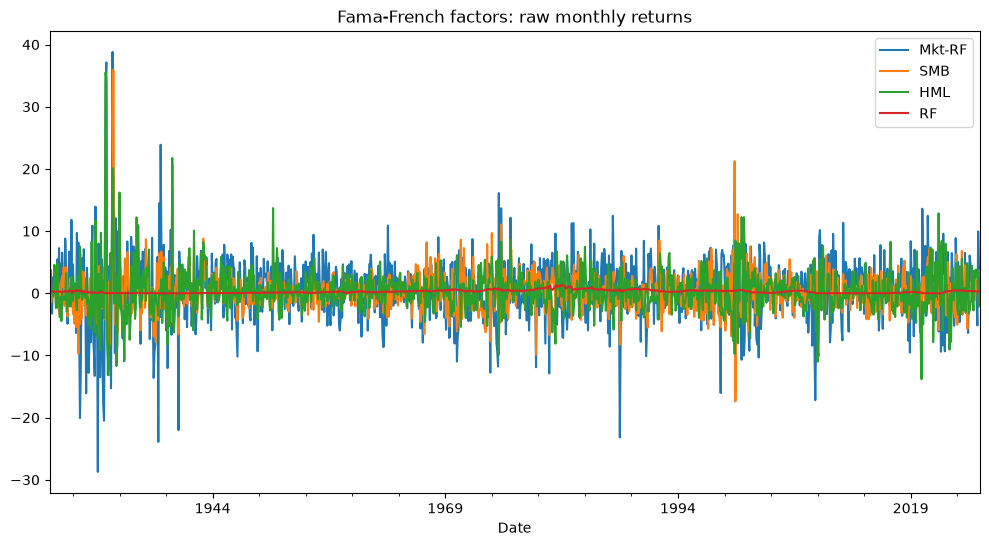

In [5]:
ff_df.plot(
    figsize=(12, 6),
    title="Fama-French factors: raw monthly returns"
)
plt.show()

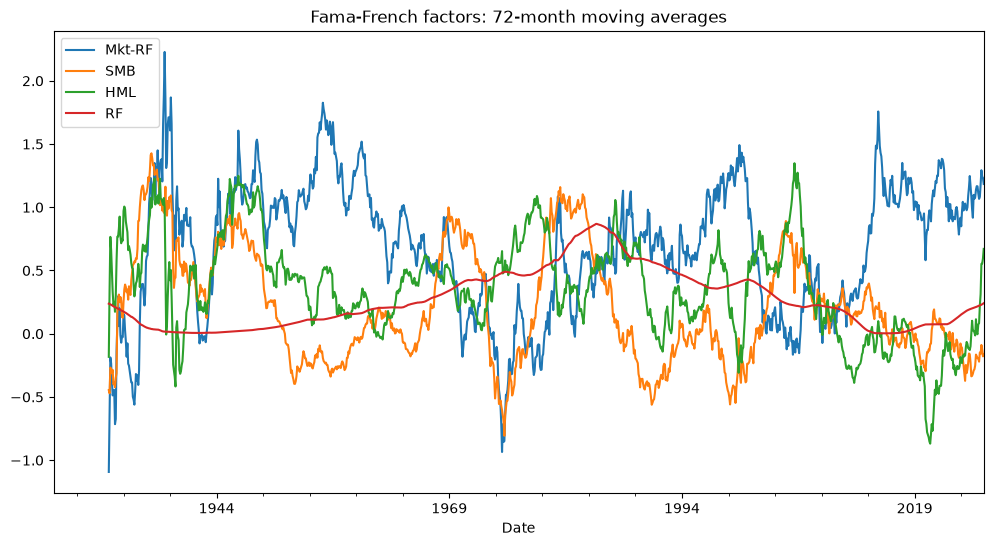

In [6]:
ff_df.rolling(window=72).mean().plot(
    figsize=(12, 6),
    title="Fama-French factors: 72-month moving averages"
)
plt.show()

## 4. Download Momentum Factor

If we want to go beyond the Fama-French 3-factor model, we can add the momentum factor. The momentum factor must be included separately.

Since we already know that pandas_datareader returns two elements and we only want the first one, we can directly take element `[0]`.

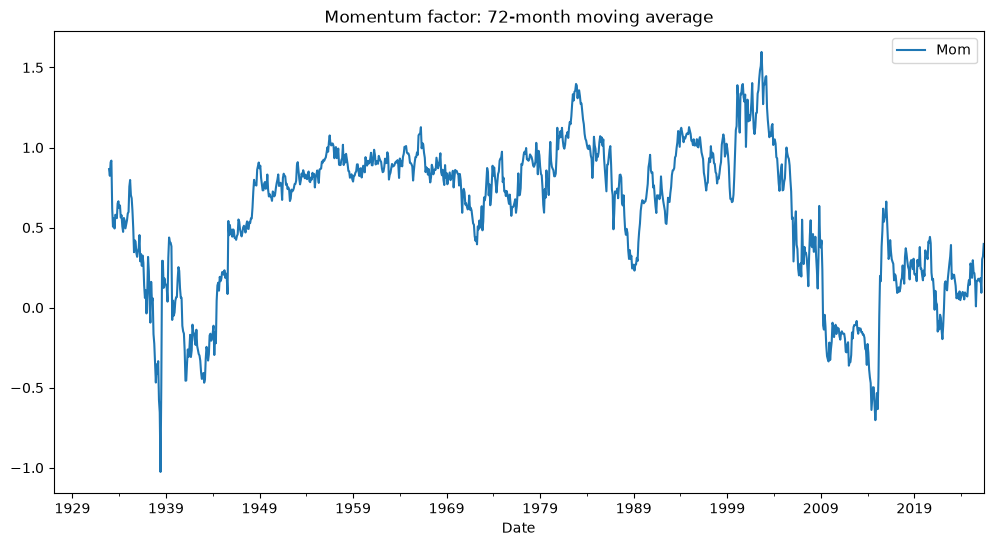

In [7]:
ff_mom_df = FamaFrenchReader(
    "F-F_Momentum_Factor",
    freq="M",
    start=start
).read()[0]

# Plot the 72-month moving average of momentum to confirm it exists.
ff_mom_df.rolling(window=72).mean().plot(
    figsize=(12, 6),
    title="Momentum factor: 72-month moving average"
)
plt.show()

## 5. Merge the Four Factor Return Series

**First data challenge:** we have one data frame with three risk factors and another data frame with one risk factor. We need one data frame with four risk factors.

pandas has a `merge` method. We can merge on a common identifier — here, the date. We use an **inner merge**, which keeps only observations where the date exists in both data frames.

Because momentum starts later than the original Fama-French data, the merged factor data should start later, likely January 1927.

The validation statement is useful: `validate="one_to_one"` tells Python we expect each date to appear only once in each data frame. If not, Python will complain.

In [8]:
fact_merged_df = pd.merge(
    ff_df,
    ff_mom_df,
    how="inner",
    left_index=True,
    right_index=True,
    sort=True,
    indicator=False,
    validate="one_to_one"
)

print(fact_merged_df.head())

         Mkt-RF   SMB   HML    RF   Mom
Date                                   
1927-01   -0.05 -0.32  4.58  0.25  0.57
1927-02    4.17  0.07  2.72  0.26 -1.51
1927-03    0.14 -1.77 -2.38  0.30  3.52
1927-04    0.47  0.39  0.65  0.25  4.35
1927-05    5.45  1.55  4.80  0.30  2.78


## 6. Download Apple Stock Data

Now we need data for the risk asset. Apple is not a Fama-French factor, so we need another database — Yahoo Finance.

For individual equities, we care about **adjusted close** because corporate actions such as splits can change the raw price series. Apple has had splits, so adjusted close is appropriate.

We want **monthly data** to match the monthly factor data. We need returns, not price levels, so we use `pct_change()`.

In [9]:
apple_raw = yf.download(
    "AAPL",
    start=start,
    interval="1mo",
    auto_adjust=False,
    actions=False,
    progress=False
)

# Some environments may return MultiIndex columns.
# This flattens the columns if needed.
if isinstance(apple_raw.columns, pd.MultiIndex):
    apple_raw.columns = apple_raw.columns.get_level_values(0)

apple_df = apple_raw[["Adj Close"]].pct_change()

print(apple_df.head())

Price       Adj Close
Date                 
1985-01-01        NaN
1985-02-01  -0.146551
1985-03-01  -0.106063
1985-04-01  -0.039546
1985-05-01  -0.182352


## 7. Align Apple and Factor Indexes

The date index looks different between Apple and the factor data. Apple has year-month-day, while Fama-French has year-month.

Apple's index is a **timestamp**, while the factor index is a **period**. This is a problem — if the data types are different, pandas cannot directly merge the frames on those indexes.

We need to reindex or create a mutually comparable date identifier. The goal is to have dates formatted exactly the same way in both frames.

`strftime("%Y-%m")` gives a year-month string.

In [10]:
print("Apple index dtype:", apple_df.index.dtype)
print("Factor index dtype:", fact_merged_df.index.dtype)

Apple index dtype: datetime64[s]
Factor index dtype: period[M]


In [11]:
# Create an intermediate string date column.
# This takes the current index and casts it to string.
#
# Then convert that string into a date and format it as year-month,
# so dates are formatted exactly the same way in both frames.
apple_df["str_date"] = apple_df.index.astype(str)
apple_df["dt_date"] = pd.to_datetime(apple_df["str_date"]).dt.strftime("%Y-%m")

fact_merged_df["str_date"] = fact_merged_df.index.astype(str)
fact_merged_df["dt_date"] = pd.to_datetime(fact_merged_df["str_date"]).dt.strftime("%Y-%m")

# Check the data type of the new date identifier.
# It is an object/string, but now it is comparable across both data frames.
print(apple_df["dt_date"].dtype)
print(fact_merged_df["dt_date"].dtype)

str
str


## 8. Merge Apple Returns with Factor Returns

Ultimately, it is easier to get everything into the same data frame so that observations line up.

For regression, the y vector and X matrix must have the same number of observations:

- y = Apple excess returns
- X = factor returns

Apple starts in 1980, while factors start in 1927. Merging helps ensure the regression uses only matching months.

After merging, we have duplicate helper string-date columns from the two original data frames, which we no longer need. We also rename Apple's return column to something more meaningful.

In [12]:
apple_fact_df = pd.merge(
    apple_df,
    fact_merged_df,
    how="inner",
    on="dt_date",
    sort=True,
    indicator=False,
    validate="one_to_one"
)

# Drop the intermediate string-date columns we no longer need.
apple_fact_df.drop(
    columns=[col for col in apple_fact_df.columns if col.startswith("str_date")],
    inplace=True
)

# Rename Apple's return column to something more meaningful.
apple_fact_df.rename(columns={"Adj Close": "APL"}, inplace=True)

## 9. Clean Column Names

In the lecture transcript, the momentum column name had trailing spaces (e.g., it appeared as something like `"MOM   "`). This caused a `KeyError` when trying to use `"MOM"` in the regression.

The fix is to strip the column names and rename the momentum column to a clean `"MOM"` version. The exact raw name may vary slightly depending on the data reader version.

In [13]:
apple_fact_df.columns = apple_fact_df.columns.str.strip()

# Rename momentum column to MOM if needed.
if "Mom" in apple_fact_df.columns:
    apple_fact_df.rename(columns={"Mom": "MOM"}, inplace=True)
elif "MOM" not in apple_fact_df.columns:
    mom_cols = [col for col in apple_fact_df.columns if col.lower().startswith("mom")]
    if mom_cols:
        apple_fact_df.rename(columns={mom_cols[0]: "MOM"}, inplace=True)

print(apple_fact_df.columns.tolist())
print(apple_fact_df.head())

['APL', 'dt_date', 'Mkt-RF', 'SMB', 'HML', 'RF', 'MOM']
        APL  dt_date  Mkt-RF   SMB   HML    RF   MOM
0       NaN  1985-01    7.97  3.27 -5.21  0.65 -6.77
1 -0.146551  1985-02    1.22  0.71 -0.24  0.58  1.91
2 -0.106063  1985-03   -0.83 -1.07  4.01  0.62  1.79
3 -0.039546  1985-04   -0.96  0.09  3.60  0.72  2.95
4 -0.182352  1985-05    5.07 -2.30 -0.98  0.66  4.05


## 10. Create Apple Excess Returns

> **Important units issue:** Fama-French factor returns are in **percent**, while Apple returns from `pct_change()` are **decimals**.

Convert Apple returns to percent by multiplying by 100. For a factor model, we also need **excess returns**: subtract the risk-free rate from Apple's return. This is why we needed Apple and the risk-free rate in the same data frame.

In [14]:
apple_fact_df["APL_RF"] = apple_fact_df["APL"] * 100 - apple_fact_df["RF"]

## 11. Drop Missing Values

> **Important Python regression point:** Unlike some statistics packages, Python regression APIs may not handle missing values automatically. It is safer to remove missing values yourself.

We then sort by date so the final data frame is orderly.

In [15]:
apple_fact_df.dropna(axis=0, inplace=True)

# Sort by date so the final data frame is orderly.
apple_fact_df.sort_values("dt_date", inplace=True, ignore_index=True)

print(apple_fact_df.head())

        APL  dt_date  Mkt-RF   SMB   HML    RF   MOM     APL_RF
0 -0.146551  1985-02    1.22  0.71 -0.24  0.58  1.91 -15.235072
1 -0.106063  1985-03   -0.83 -1.07  4.01  0.62  1.79 -11.226273
2 -0.039546  1985-04   -0.96  0.09  3.60  0.72  2.95  -4.674615
3 -0.182352  1985-05    5.07 -2.30 -0.98  0.66  4.05 -18.895181
4  0.035969  1985-06    1.27  0.48  0.38  0.55  3.39   3.046907


## 12. Run Factor Model Regression

We use **statsmodels** for regression because it gives more user-friendly regression output than scikit-learn. We mainly want to look at factor exposures.

Regression setup:

- y = `APL_RF`, Apple's monthly excess return
- X = market, size, value, and momentum factor returns (`Mkt-RF`, `SMB`, `HML`, `MOM`)

In [16]:
import statsmodels.api as sm
import statsmodels.tools.tools as sm_tools

x_cols = ["Mkt-RF", "SMB", "HML", "MOM"]

assert all(col in apple_fact_df.columns for col in x_cols), (
    "Missing one or more factor columns after cleaning."
)

### Regression without intercept

This first regression works, but a financial economist would notice that it does not include an intercept. A proper factor model should have an intercept, also called **alpha**.

In [17]:
results_no_const = sm.OLS(
    apple_fact_df["APL_RF"],
    apple_fact_df[x_cols]
).fit()

print(results_no_const.summary())

                                 OLS Regression Results                                
Dep. Variable:                 APL_RF   R-squared (uncentered):                   0.300
Model:                            OLS   Adj. R-squared (uncentered):              0.294
Method:                 Least Squares   F-statistic:                              52.75
Date:                Sat, 08 Aug 2026   Prob (F-statistic):                    5.39e-37
Time:                        16:30:42   Log-Likelihood:                         -1858.5
No. Observations:                 497   AIC:                                      3725.
Df Residuals:                     493   BIC:                                      3742.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Add constant / intercept

We need to fix the missing intercept.

> **Important Python point:** Python does not automatically include a constant in OLS. Unless you give it a column of ones, it will not include an intercept. `statsmodels.tools.tools.add_constant` adds that column of ones.

Mathematically, this column of ones is required if you want an intercept in the X matrix.

In [18]:
apple_fact_df_c = sm_tools.add_constant(apple_fact_df, prepend=True)

x_cols_c = ["const"] + x_cols

results = sm.OLS(
    apple_fact_df_c["APL_RF"],
    apple_fact_df_c[x_cols_c]
).fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 APL_RF   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     50.90
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           7.36e-36
Time:                        16:30:42   Log-Likelihood:                -1853.5
No. Observations:                 497   AIC:                             3717.
Df Residuals:                     492   BIC:                             3738.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4811      0.470      3.149      0.0

## 13. Adjusted R-squared as a Tool for Model Assessment

In the regression output above, statsmodels reports two quantities: `R-squared` and `Adj. R-squared`. The two answer slightly different questions.

Recall that **R-squared** measures how much of the variability in the outcome is explained by the model:

$$
R^2 = 1 - \frac{\text{Var}(e_i)}{\text{Var}(y_i)}
$$

where $e_i$ are the residuals and $y_i$ the outcomes. In a regression of Apple's excess return on the four factors, $R^2 = 0.293$: the factor model explains about **29.3%** of the month-to-month variation in Apple's excess return, leaving a large idiosyncratic component.

This formula remains valid with multiple predictors, but the plain $R^2$ becomes an **overly optimistic** estimate of explanatory power as we add variables. Adding any predictor -- even a useless one -- can only decrease the residual variance (or leave it unchanged), so plain $R^2$ tends to creep up with $k$ even when the new variable has no real relationship with the outcome. It is a biased estimate of the amount of variability explained when the model has more than one predictor.

The **adjusted R-squared** corrects for this by penalizing the number of predictors, using the degrees of freedom of each variance ($n - k - 1$ for residuals vs $n - 1$ for the outcome):

$$
R^2_{\text{adj}} = 1 - \frac{s^2_{\text{resid}} / (n - k - 1)}{s^2_{\text{outcome}} / (n - 1)} = 1 - \frac{s^2_{\text{resid}}}{s^2_{\text{outcome}}} \times \frac{n - 1}{n - k - 1}
$$

where:

- $n$ is the number of observations used to fit the model,
- $k$ is the number of predictor variables (a categorical predictor with $p$ levels contributes $p - 1$ variables).

Because $k$ is never negative, the adjusted $R^2$ is always a bit **smaller** than the unadjusted $R^2$. The penalty grows with $k$, so adjusted $R^2$ is the more honest number to compare across models with different numbers of factors. In our regression $R^2 = 0.293$ while $R^2_{\text{adj}} = 0.287$; the small gap ($n = 497$, $k = 4$) reflects the mild penalty for the four predictors.

If we were to use the model to predict new data, the unadjusted $R^2$ would tend to be slightly overly optimistic, while the adjusted $R^2$ formula corrects for this bias.

In [ ]:
# Verify statsmodels' adjusted R-squared by hand.
n = int(results.nobs)
k = len(x_cols)  # number of predictors, excluding the constant

r2 = results.rsquared
r2_adj_sm = results.rsquared_adj

# Adjusted R^2 = 1 - (1 - R^2) * (n - 1) / (n - k - 1)
r2_adj_manual = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("n =", n, "| k =", k)
print("R-squared (statsmodels):     ", round(r2, 4))
print("Adj R-squared (statsmodels): ", round(r2_adj_sm, 4))
print("Adj R-squared (by hand):     ", round(r2_adj_manual, 4))

## 14. Extract Factor Exposures and Idiosyncratic Risk

The original objective was to get:

1. **Factor exposures**
2. **Idiosyncratic risk**

Idiosyncratic risk is the part of Apple's return that is not explained by the risk model. One simple measure is the standard deviation of the regression residuals.

Optionally, we annualize: the regression uses monthly data, so multiply by $\sqrt{12}$.

In [19]:
factor_exposures = results.params[x_cols]
alpha = results.params["const"]
r_squared = results.rsquared

# Idiosyncratic risk is the part of Apple's return that is not
# explained by the risk model. One simple measure is the standard
# deviation of the regression residuals.
idiosyncratic_vol = results.resid.std()

# Optional annualization: multiply by sqrt(12) to annualize.
idiosyncratic_vol_annualized = idiosyncratic_vol * (12 ** 0.5)

print("Factor exposures (betas):")
print(factor_exposures)

print("Alpha (percent per month):", alpha)
print("R-squared:", r_squared)

print("Idiosyncratic monthly return volatility:", idiosyncratic_vol)
print("Idiosyncratic annualized return volatility:", idiosyncratic_vol_annualized)

Factor exposures (betas):
Mkt-RF    1.132817
SMB       0.230163
HML      -0.882333
MOM      -0.191802
dtype: float64
Alpha (percent per month): 1.4810807024529287
R-squared: 0.29269455311836723
Idiosyncratic monthly return volatility: 10.089071913398763
Idiosyncratic annualized return volatility: 34.94957031044561


## 15. Interpretation

In the lecture, Apple's factor regression produced the following results (your numbers may differ because the data sample updates over time):

- Apple's **alpha** was positive and highly significant, about **1.4% per month**.
- Apple had a significant **market exposure**, with beta about **1.2**.
- Apple had an **insignificant exposure to size** (SMB).
- Apple had a **negative significant exposure to value** (HML), which makes sense because Apple is a growth stock.
- Apple had an **insignificant exposure to momentum** in that example.
- R-squared was about **28%**, suggesting a fairly large idiosyncratic component.

Note: if you run the code today, your numbers may differ because the data sample updates over time.